In [12]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [4]:
X ,y = make_classification(n_samples =1000 , n_features=10 ,n_classes =2 , random_state=42)

In [9]:
X.shape
y.shape

(1000,)

In [11]:
X_train = X
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
995,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
996,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
997,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
998,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [17]:
X_train , X_test ,y_train , y_test = train_test_split(X,y , test_size = 0.30 , random_state = 42)
m,n = X_train.shape

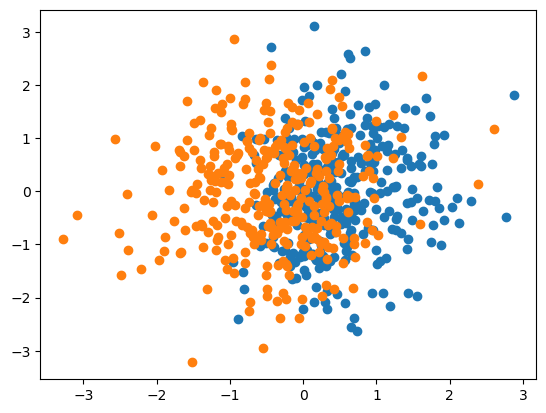

In [15]:
plt.scatter(X_train[y_train ==0 , 0] , X_train[y_train == 0,1], color = 'tab:blue' )
plt.scatter(X_train[y_train == 1, 0] , X_train[y_train == 1,1], color = 'tab:orange' )

In [25]:
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [30]:
def cost_function(X,y,w,b):
    cost_sum = 0

    for i in range(m):
        z = np.dot(w,X[i])+ b
        g = sigmoid(z)
        cost_sum += -y[i] * np.log(g) - (1-y[i]) * np.log(1-g)
    return (1/m)*cost_sum

In [31]:
def gradient_function(X,y,w,b):
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z=np.dot(w,X[i] + b)
        g = sigmoid(z)
        grad_b += (g-y[i])
        for j in range(n):
            grad_w[j] += (g-y[i]) * X[i,j]
    grad_b = (1/m) * grad_b
    grad_w = (1/m) * grad_w
    return grad_b , grad_w

In [34]:
def gradient_decent(X,y,alpha , iter):
    w=np.zeros(n)
    b = 0
    for i in range(iter):
        grad_b , grad_w = gradient_function(X,y,w,b)
        w= w-alpha * grad_w
        b = b - alpha * grad_b

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost{cost_function(X,y,w,b)}")
    return w , b 

In [33]:
def predict(X,w,b):
    preds = np.zeros(m)
    for i in range(m):
        z = np.dot(w,X[i]) + b
        g = sigmoid(z)
        
        preds[i] = 1 if g >= 0.5 else 0 
    return preds


In [35]:
learning_rate = 0.01
iter = 10000
final_w , final_b = gradient_decent(X_train ,y_train , learning_rate , iter)
predictions = predict(X_train,final_w , final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"traning accuracy: {accuracy:2f}%")

Iteration 0: Cost0.6894436493856722
Iteration 1000: Cost0.33554191969276786
Iteration 2000: Cost0.3254426378486678
Iteration 3000: Cost0.32394122379761997
Iteration 4000: Cost0.3261525116442084
Iteration 5000: Cost0.3344454106722114
Iteration 6000: Cost0.3558184506407833
Iteration 7000: Cost0.40580973324043385
Iteration 8000: Cost0.5175024689950565
Iteration 9000: Cost0.7539075909481918
traning accuracy: 57.571429%


5
